In [1]:
# Install required packages
# Use prebuilt wheels for torch-scatter/torch-sparse to avoid slow source builds
import torch
tv = torch.__version__.split('+')[0]   # e.g. '2.6.0'
cv = torch.version.cuda.replace('.', '')  # e.g. '124'
whl = f'https://data.pyg.org/whl/torch-{tv}+cu{cv}.html'
print(f'PyG wheel index: {whl}')
!pip install -q torch-scatter torch-sparse -f {whl}
!pip install -q torch-geometric scipy pandas matplotlib seaborn tqdm pyarrow fastparquet scikit-learn

PyG wheel index: https://data.pyg.org/whl/torch-2.11.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 124.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 85.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 83.5 MB/s eta 0:00:00


In [2]:
# Clone the repository and add src to sys.path
import os
import sys

REPO_ROOT = '/content/antenna-gnn'

if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
else:
    !cd {REPO_ROOT} && git pull

if f'{REPO_ROOT}/src' not in sys.path:
    sys.path.insert(0, f'{REPO_ROOT}/src')

Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 311, done.
remote: Counting objects: 100% (311/311), done.
remote: Compressing objects: 100% (182/182), done.
remote: Total 311 (delta 163), reused 260 (delta 114), pack-reused 0 (from 0)
Receiving objects: 100% (311/311), 7.72 MiB | 25.01 MiB/s, done.
Resolving deltas: 100% (163/163), done.


In [3]:
# Mount Google Drive and set data paths
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA = '/content/drive/MyDrive/antenna_dataset'

# Create necessary directories in DATA_ROOT
os.makedirs(f'{DATA_ROOT}/artifacts', exist_ok=True)
os.makedirs(f'{DATA_ROOT}/figures', exist_ok=True)
os.makedirs(f'{DATA_ROOT}/checkpoints', exist_ok=True)

Mounted at /content/drive


---
## Cell A — Architecture Change (Minimal and Reversible)

**Purpose:** Subclass `AntennaGNN` to add a binary classification head tapping the existing 256-d readout embedding vector.
- Reads out `(spectrum_201, cls_logit)`.
- Reuses frozen backbone and projection weights from `best_model.pt` via `strict=False`.
- Verifies exact parameter count ($587,001 + 257 = 587,258$) and state_dict diff against `best_model.pt`.
- Loads the identical 2,000-sample training subset from Chunk 22 (`ch22_subset_2000.json`) and the 1,496-sample validation split with local SSD caching and canonical normalization guard.

In [4]:
# ==========================================================================
# CELL A — Architecture Change (Minimal and Reversible)
# ==========================================================================

import json
import hashlib
import shutil
import time
import copy
import subprocess
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from collections import defaultdict
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import Dataset as TorchDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
from scipy.signal import find_peaks
from scipy import stats as scipy_stats
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve,
                             balanced_accuracy_score, f1_score,
                             precision_score, recall_score,
                             confusion_matrix)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from tqdm.notebook import tqdm
from model import AntennaGNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Disable TF32 for numerical consistency
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
print('TF32 disabled')

# ── FinetuneDataset — frozen from Chunk 13 ──
class FinetuneDataset(TorchDataset):
    """Fine-tune graph dataset with mandatory z-score normalization at load.

    On-disk data.y is raw dB. This dataset z-scores y at load time using
    the 25x25 training-split s11_mean / s11_std, and preserves y_raw.
    evaluate() de-normalizes with the same statistics.
    """

    def __init__(self, indices, processed_dir_base, s11_mean, s11_std):
        assert s11_mean is not None, 'FinetuneDataset requires s11_mean (got None)'
        assert s11_std is not None,  'FinetuneDataset requires s11_std (got None)'
        self.indices = indices
        self.processed_dir_base = processed_dir_base
        self.s11_mean = s11_mean   # (201,) tensor
        self.s11_std  = s11_std    # (201,) tensor

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        grid_size, local_idx = self.indices[idx]
        path = f'{self.processed_dir_base}/{grid_size}x{grid_size}/sample_{local_idx}.pt'
        data = torch.load(path, weights_only=False)

        # Preserve raw dB target, then z-score
        data.y_raw = data.y.clone()                              # (1, 201) raw dB
        data.y = (data.y - self.s11_mean) / (self.s11_std + 1e-8)  # (1, 201) normalized

        return data


# ── Frequency axis ──
freq_axis = np.linspace(1.0, 4.0, 201)

# ── Load normalization statistics ──
s11_mean_np = np.load(f'{DATA_ROOT}/artifacts/s11_mean.npy')
s11_std_np  = np.load(f'{DATA_ROOT}/artifacts/s11_std.npy')
s11_mean_cpu = torch.tensor(s11_mean_np, dtype=torch.float32)
s11_std_cpu  = torch.tensor(s11_std_np,  dtype=torch.float32)
s11_mean_dev = s11_mean_cpu.to(device)
s11_std_dev  = s11_std_cpu.to(device)
assert s11_mean_cpu.shape == (201,) and s11_std_cpu.shape == (201,)
print(f'Loaded s11_mean and s11_std, shape (201,)')

# ── Load splits ──
with open(f'{DATA_ROOT}/splits/finetune_pool_indices.json') as f:
    pool_indices = json.load(f)
with open(f'{DATA_ROOT}/splits/finetune_val_indices.json') as f:
    val_indices = json.load(f)

# Guard: Test split is never loaded in this notebook
TEST_INDICES_LOADED = False

print(f'Pool: {len(pool_indices)}, Val: {len(val_indices)}')

# ── Load the EXACT 2,000-sample subset from Chunk 22 ──
subset_path = f'{DATA_ROOT}/artifacts/ch22_subset_2000.json'
assert os.path.exists(subset_path), (
    f'{subset_path} not found. Run Chunk 22 Cell A first.')
with open(subset_path) as f:
    subset_indices = json.load(f)
print(f'Loaded ch22 subset: {len(subset_indices)} samples')

SUBSET_HASH = hashlib.sha256(
    json.dumps(subset_indices, sort_keys=True).encode()).hexdigest()
print(f'Subset hash: {SUBSET_HASH[:16]}...')

# ── Local disk staging for fast I/O ──
processed_dir = f'{DATA_ROOT}/data/processed_finetune'
STAGE_LOCALLY = True

if STAGE_LOCALLY:
    drive_dir = f'{DATA_ROOT}/data/processed_finetune'
    local_dir = '/content/processed_finetune'
    try:
        needed = set()
        for gs, li in subset_indices + val_indices:
            needed.add((gs, li))
        n_need = len(needed)
        print(f'Staging {n_need} unique files (subset + val) to local disk...')

        probe_idx = list(needed)[:20]
        probe_sizes = []
        for gs, li in probe_idx:
            p = f'{drive_dir}/{gs}x{gs}/sample_{li}.pt'
            if os.path.exists(p):
                probe_sizes.append(os.path.getsize(p))
        est_gb = (sum(probe_sizes) / len(probe_sizes)) * n_need / 1e9 if probe_sizes else 0
        free_gb = shutil.disk_usage('/content').free / 1e9
        print(f'~{est_gb:.2f} GB estimated, {free_gb:.1f} GB free on /content')
        assert free_gb > est_gb * 1.5, 'not enough local disk space'

        t0 = time.time()
        os.makedirs(local_dir, exist_ok=True)
        n_copied = 0
        for gs, li in tqdm(sorted(needed), desc='Staging needed files'):
            src_path = f'{drive_dir}/{gs}x{gs}/sample_{li}.pt'
            dst_dir = f'{local_dir}/{gs}x{gs}'
            dst_path = f'{dst_dir}/sample_{li}.pt'
            if not os.path.exists(dst_path):
                os.makedirs(dst_dir, exist_ok=True)
                shutil.copy2(src_path, dst_path)
                n_copied += 1
        print(f'Staged {n_copied} new files ({n_need} total) in {time.time() - t0:.1f} s')
        processed_dir = local_dir
        print(f'processed_dir -> {processed_dir}')
    except Exception as e:
        print(f'Staging skipped ({type(e).__name__}: {e}); continuing from Drive')

# ── Build DataLoaders ──
train_ds = FinetuneDataset(subset_indices, processed_dir, s11_mean_cpu, s11_std_cpu)
val_ds   = FinetuneDataset(val_indices, processed_dir, s11_mean_cpu, s11_std_cpu)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,
                          num_workers=0, generator=torch.Generator().manual_seed(42))
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

print(f'\nTrain: {len(train_ds)}, Val: {len(val_ds)}')
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

# ── Canonical Normalization Guard ──
probe_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
ys, yr = [], []
for b in tqdm(probe_loader, desc='Normalization Guard'):
    ys.append(b.y.view(-1, 201))
    yr.append(b.y_raw.view(-1, 201))
all_y, all_raw = torch.cat(ys), torch.cat(yr)

assert hasattr(val_ds[0], 'y_raw'), 'y_raw missing'
assert not torch.allclose(all_y, all_raw), 'y == y_raw — normalization is a no-op'
recon = all_y * s11_std_cpu + s11_mean_cpu
maxdiff = (recon - all_raw).abs().max().item()
assert maxdiff < 1e-3, f'round trip FAILED: max diff {maxdiff:.6f}'
assert all_raw.max().item() <= 0.01, f'raw y max {all_raw.max().item():.3f} > 0 dB'
print(f'[PASS] Normalization guard passed (round trip max diff: {maxdiff:.2e})')
del probe_loader, ys, yr, all_y, all_raw, recon

# ── Git Revision ──
try:
    GIT_SHA = subprocess.check_output(
        ['git', 'rev-parse', '--short', 'HEAD'],
        cwd=REPO_ROOT, stderr=subprocess.DEVNULL
    ).decode().strip()
except Exception:
    GIT_SHA = 'unknown'
print(f'Git SHA: {GIT_SHA}')


# ═══════════════════════════════════════════════════════════════════════════
# Architecture: AntennaGNNMultiTask
# ═══════════════════════════════════════════════════════════════════════════

class AntennaGNNMultiTask(AntennaGNN):
    """AntennaGNN extended with an auxiliary classification head.

    Taps the exact 256-d readout representation before output_mlp:
        self.cls_head = nn.Linear(256, 1)
    Returns:
        (spectrum_201, cls_logit)
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.cls_head = nn.Linear(256, 1)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        batch = data.batch

        x = self.input_proj(x)
        edge_attr = self.edge_proj(edge_attr)

        for block in self.blocks:
            for layer in block:
                x = layer(x, edge_index, edge_attr)

        # Metal-only pooling (identical to AntennaGNN)
        metal_mask = data.x[:, 0] > 0.5
        metal_x = x[metal_mask]
        metal_batch = batch[metal_mask]
        pooled = global_mean_pool(metal_x, metal_batch)

        # Virtual node embedding (identical to AntennaGNN)
        virtual_mask = data.x[:, 3] == -1
        virtual_x = x[virtual_mask]

        combined = torch.cat([pooled, virtual_x], dim=-1)

        # Tap the same 256-d readout representation
        h = self.readout_proj(combined)            # (B, 256)
        spectrum = self.output_mlp(h)              # (B, 201)
        cls_logit = self.cls_head(h).squeeze(-1)    # (B,)

        return spectrum, cls_logit


# ── Load best_model.pt and verify weight compatibility ──
model_mt = AntennaGNNMultiTask(
    hidden_dim=128, heads=8, edge_dim=16,
    num_blocks=4, output_dim=201)

ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt',
                   map_location='cpu', weights_only=False)

missing, unexpected = model_mt.load_state_dict(
    ckpt['model_state'], strict=False)

print(f'\nLoaded best_model.pt with strict=False:')
print(f'  Missing keys (new cls_head):   {missing}')
print(f'  Unexpected keys:               {unexpected}')

assert set(missing) == {'cls_head.weight', 'cls_head.bias'}, \
    f'Expected only cls_head keys missing, got: {missing}'
assert len(unexpected) == 0, \
    f'Unexpected keys in checkpoint: {unexpected}'

# ── Parameter Count Guard ──
n_params = sum(p.numel() for p in model_mt.parameters())
print(f'\nTotal Parameters: {n_params:,}')
assert n_params == 587_258, \
    f'Expected 587,258 params (587,001 + 257), got {n_params:,}'
print(f'[PASS] Parameter count: 587,001 (AntennaGNN) + 257 (cls_head) = 587,258')

# ── State Dict Key Diff Guard ──
old_keys = set(ckpt['model_state'].keys())
new_keys = set(model_mt.state_dict().keys())
added = new_keys - old_keys
removed = old_keys - new_keys
print(f'\nState dict diff vs best_model.pt:')
print(f'  Added keys:   {sorted(added)}')
print(f'  Removed keys: {sorted(removed)}')
assert added == {'cls_head.weight', 'cls_head.bias'}, \
    f'Only cls_head tensors should be new, got: {added}'
assert len(removed) == 0, f'Unexpected keys removed: {removed}'
print(f'[PASS] Only new keys are cls_head.weight and cls_head.bias')

del model_mt, ckpt
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Device: cuda
TF32 disabled
Loaded s11_mean and s11_std, shape (201,)
Pool: 11971, Val: 1496
Loaded ch22 subset: 2000 samples
Subset hash: 2bd670ddd6b55a20...
Staging 3496 unique files (subset + val) to local disk...
~1.03 GB estimated, 70.2 GB free on /content


Staging needed files:   0%|          | 0/3496 [00:00<?, ?it/s]

Staged 3496 new files (3496 total) in 852.0 s
processed_dir -> /content/processed_finetune

Train: 2000, Val: 1496
Train batches: 16, Val batches: 47


Normalization Guard:   0%|          | 0/24 [00:00<?, ?it/s]

[PASS] Normalization guard passed (round trip max diff: 1.91e-06)
Git SHA: da00a7f

Loaded best_model.pt with strict=False:
  Missing keys (new cls_head):   ['cls_head.weight', 'cls_head.bias']
  Unexpected keys:               []

Total Parameters: 587,258
[PASS] Parameter count: 587,001 (AntennaGNN) + 257 (cls_head) = 587,258

State dict diff vs best_model.pt:
  Added keys:   ['cls_head.bias', 'cls_head.weight']
  Removed keys: []
[PASS] Only new keys are cls_head.weight and cls_head.bias


---
## Cell B — Multi-Task Loss & Balance Calibration

`L_total = L_spectrum + gamma * BCEWithLogitsLoss(cls_logit, is_functioning)`

- **L_spectrum:** Uses Chunk 22's winning spectrum loss arm **L2 (Weighted MSE)**, where $w = \sigma^2 / \text{mean}(\sigma^2)$.
- **Class Imbalance Check:** Evaluates positive-class rate on the 2,000-sample training subset. Pos-weight is applied only if the rate lies outside $[0.35, 0.65]$.
- **Auto-calibrated $\gamma$:** Initialized on the first mini-batch so that the classification BCE loss contributes $\sim 20\%$ of the total loss at step 0, and then frozen.

In [5]:
# ==========================================================================
# CELL B — Multi-Task Loss & Balance Calibration
# ==========================================================================

# ── Spectrum Loss Choice ──
CH22_WINNER = 'L2'
print(f'Spectrum Loss Arm: {CH22_WINNER} (Weighted MSE) — '
      f'selected from Chunk 22 Cell G WINNER evaluation')

# ── L2 Frequency-Weighting Buffer ──
std_sq = s11_std_cpu ** 2
w_cpu = std_sq / std_sq.mean()  # (201,), unit-mean
w_dev = w_cpu.to(device)
print(f'L2 Weight Buffer: shape {w_dev.shape}, min={w_dev.min():.4f}, '
      f'max={w_dev.max():.4f}, mean={w_dev.mean():.4f}')


def loss_L2(pred_norm, y):
    """Weighted MSE (Chunk 22 Arm L2) on normalized target y."""
    return ((pred_norm - y) ** 2 * w_dev).mean()


# ── Positive-Class Rate & pos_weight Check ──
n_pos = 0
n_total = 0
for batch in tqdm(train_loader, desc='Checking training class balance'):
    is_func = batch.is_functioning
    if isinstance(is_func, torch.Tensor):
        n_pos += is_func.sum().item()
        n_total += len(is_func)
    else:
        n_pos += sum(bool(x) for x in is_func)
        n_total += len(is_func)

pos_rate = n_pos / n_total
neg_rate = 1.0 - pos_rate
implied_pos_weight = neg_rate / pos_rate if pos_rate > 0 else 1.0

print(f'\nTraining subset: {n_pos}/{n_total} functioning '
      f'({pos_rate * 100:.2f}% positive rate)')
print(f'Implied pos_weight: {implied_pos_weight:.3f}')

USE_POS_WEIGHT = pos_rate < 0.35 or pos_rate > 0.65
if USE_POS_WEIGHT:
    pw = torch.tensor([implied_pos_weight], device=device)
    print(f'pos_rate {pos_rate:.3f} outside [0.35, 0.65] -> USING pos_weight={implied_pos_weight:.3f}')
else:
    pw = None
    print(f'pos_rate {pos_rate:.3f} inside [0.35, 0.65] -> NOT using pos_weight (mild imbalance)')

bce_fn = nn.BCEWithLogitsLoss(pos_weight=pw)

# ── Auto-Scale Gamma on Initial Batch ──
probe_model = AntennaGNNMultiTask(
    hidden_dim=128, heads=8, edge_dim=16,
    num_blocks=4, output_dim=201)
ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt',
                   map_location='cpu', weights_only=False)
probe_model.load_state_dict(ckpt['model_state'], strict=False)
probe_model = probe_model.to(device)
probe_model.eval()
del ckpt

probe_batch = next(iter(train_loader)).to(device)

with torch.no_grad():
    spectrum, cls_logit = probe_model(probe_batch)
    y = probe_batch.y.squeeze(1)
    is_func = probe_batch.is_functioning
    if not isinstance(is_func, torch.Tensor):
        is_func = torch.tensor(is_func, dtype=torch.float32)
    is_func = is_func.float().to(device)

    l_spec = loss_L2(spectrum, y)
    l_bce = bce_fn(cls_logit, is_func)

    # Set gamma so BCE term is ~20% of total loss at initialization
    # total = l_spec + gamma * l_bce => (gamma * l_bce) / total = 0.20
    # gamma * l_bce = 0.20 * l_spec / 0.80 = 0.25 * l_spec
    GAMMA = float(0.25 * l_spec.item() / l_bce.item()) if l_bce.item() > 0 else 0.0

print(f'\nAuto-calibrated gamma = {GAMMA:.6f}')
print(f'  L_spectrum (init) = {l_spec.item():.4f}')
print(f'  L_BCE      (init) = {l_bce.item():.4f}')
print(f'  gamma * L_BCE     = {GAMMA * l_bce.item():.4f} '
      f'({GAMMA * l_bce.item() / (l_spec.item() + GAMMA * l_bce.item()) * 100:.1f}% of total initial loss)')
print(f'  gamma is FROZEN for all subsequent training')

del probe_model, probe_batch
if torch.cuda.is_available():
    torch.cuda.empty_cache()


def loss_total(spectrum, cls_logit, batch):
    """Multi-task loss: L_spectrum (L2) + gamma * BCE.

    Returns:
        (total_loss_tensor, l_spec_scalar, l_bce_scalar)
    """
    y = batch.y.squeeze(1)
    is_func = batch.is_functioning
    if not isinstance(is_func, torch.Tensor):
        is_func = torch.tensor(is_func, dtype=torch.float32)
    is_func = is_func.float().to(device)

    l_spec = loss_L2(spectrum, y)
    l_bce = bce_fn(cls_logit, is_func)
    total = l_spec + GAMMA * l_bce

    return total, l_spec.item(), l_bce.item()


print(f'\n[PASS] Multi-task loss configured (L2 + {GAMMA:.4f} * BCE)')

Spectrum Loss Arm: L2 (Weighted MSE) — selected from Chunk 22 Cell G WINNER evaluation
L2 Weight Buffer: shape torch.Size([201]), min=0.0000, max=9.2786, mean=1.0000


Checking training class balance:   0%|          | 0/16 [00:00<?, ?it/s]


Training subset: 1225/2000 functioning (61.25% positive rate)
Implied pos_weight: 0.633
pos_rate 0.613 inside [0.35, 0.65] -> NOT using pos_weight (mild imbalance)

Auto-calibrated gamma = 0.174980
  L_spectrum (init) = 0.5004
  L_BCE      (init) = 0.7150
  gamma * L_BCE     = 0.1251 (20.0% of total initial loss)
  gamma is FROZEN for all subsequent training

[PASS] Multi-task loss configured (L2 + 0.1750 * BCE)


---
## Cell C — Multi-Task Fine-Tuning & Gradient-Interference Monitoring

- **Training Setup:** Trained on the exact 2,000-sample subset (`ch22_subset_2000.json`) with seed 42.
- **Warm-start:** Pretrained backbone initialized from `best_model.pt`, with `cls_head` trained from scratch.
- **Optimization:** Adam (`lr=1e-4`, `weight_decay=1e-4`), `batch_size=128`, gradient clipping at `1.0`.
- **Early Stopping & Validation:** Monitored on total validation loss (`patience=10`, `max_epochs=60`).
- **Gradient-Interference Tracking:** Logs and plots Validation S11 MAE (dB) and Validation BCE loss alongside total loss to visually detect multi-task interference.
- **Artifacts:** Checkpoint saved to `DATA_ROOT/checkpoints/ch23_multitask.pt` and metadata to `ch23_multitask_provenance.json`.

<>:186: SyntaxWarning: invalid escape sequence '\g'
<>:186: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1015/1153782524.py:186: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title('Total Loss ($L_{spec} + \gamma L_{BCE}$)')


Training Multi-Task Model:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/16 [00:00<?, ?it/s]

  E01: train_total=0.4905 | val_total=0.3960 | val_s11_mae=0.4858 dB | val_bce=0.5733 | lr=1.00e-04


Epoch 2:   0%|          | 0/16 [00:00<?, ?it/s]

...

  E32: train_total=0.2440 | val_total=0.3093 | val_s11_mae=0.3620 dB | val_bce=0.3908 | lr=5.00e-05


Epoch 33:   0%|          | 0/16 [00:00<?, ?it/s]

  E33: train_total=0.2444 | val_total=0.3111 | val_s11_mae=0.3615 dB | val_bce=0.3911 | lr=5.00e-05


Epoch 34:   0%|          | 0/16 [00:00<?, ?it/s]

  E34: train_total=0.2464 | val_total=0.3113 | val_s11_mae=0.3644 dB | val_bce=0.3905 | lr=5.00e-05
  Early stopping triggered at epoch 34

Training complete in 6.9 min.
Best Epoch: 24 | Best Val Loss: 0.3052
[PASS] Saved /content/drive/MyDrive/antenna_gnn/checkpoints/ch23_multitask.pt and /content/drive/MyDrive/antenna_gnn/checkpoints/ch23_multitask_provenance.json


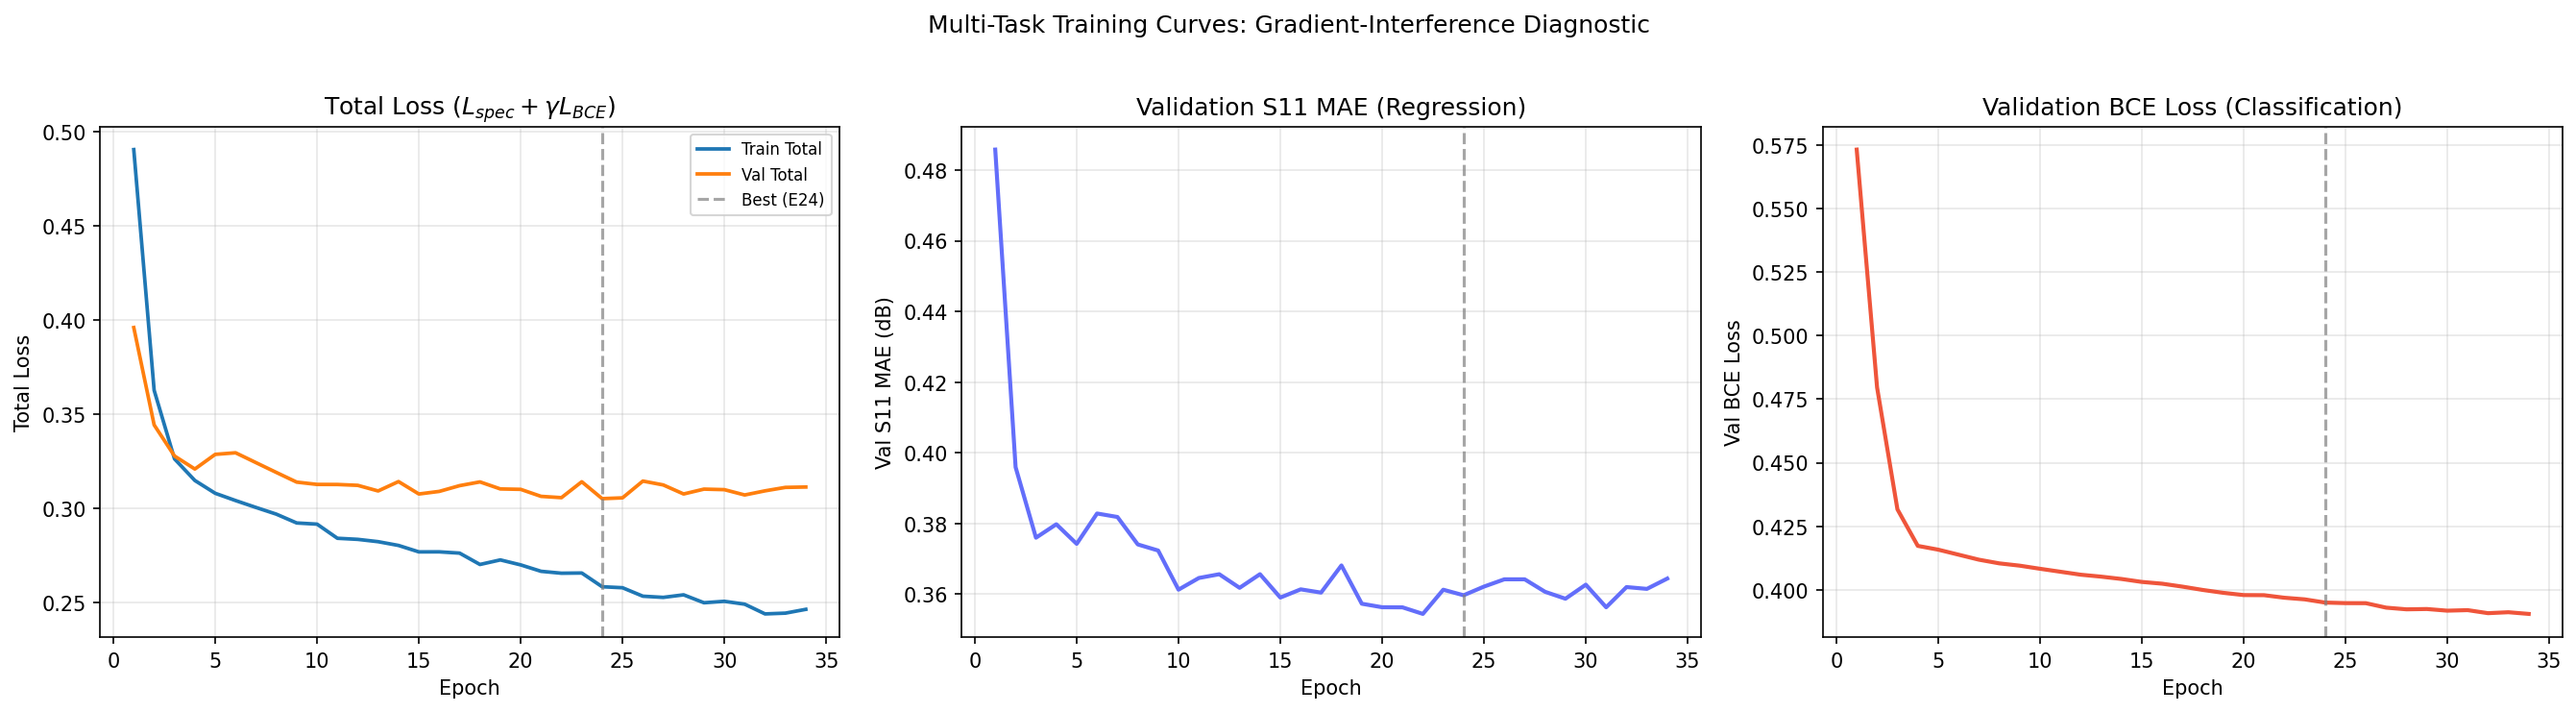

[PASS] Saved figures/ch23_training_curves.png


In [6]:
# ==========================================================================
# CELL C — Multi-Task Fine-Tuning & Gradient-Interference Monitoring
# ==========================================================================

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

torch.manual_seed(42)
np.random.seed(42)

model = AntennaGNNMultiTask(
    hidden_dim=128, heads=8, edge_dim=16,
    num_blocks=4, output_dim=201)

# Warm-start backbone from best_model.pt
ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt',
                   map_location='cpu', weights_only=False)
model.load_state_dict(ckpt['model_state'], strict=False)
model = model.to(device)
del ckpt

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

MAX_EPOCHS = 60
PATIENCE = 10
MAX_NORM = 1.0

best_val_loss = float('inf')
best_state = None
best_epoch = -1
epochs_no_improve = 0
history = []

t0_wall = time.time()

for epoch in tqdm(range(MAX_EPOCHS), desc='Training Multi-Task Model'):
    # ── Train Step ──
    model.train()
    epoch_total, epoch_spec, epoch_bce = 0.0, 0.0, 0.0
    n_batches = 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}', leave=False):
        batch = batch.to(device)
        optimizer.zero_grad()
        spectrum, cls_logit = model(batch)
        total, s_val, b_val = loss_total(spectrum, cls_logit, batch)
        total.backward()
        clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad],
            max_norm=MAX_NORM)
        optimizer.step()

        epoch_total += total.item()
        epoch_spec += s_val
        epoch_bce += b_val
        n_batches += 1

    avg_total = epoch_total / n_batches
    avg_spec = epoch_spec / n_batches
    avg_bce = epoch_bce / n_batches

    # ── Validation Step ──
    model.eval()
    val_totals, val_specs, val_bces = [], [], []
    val_s11_errors = []

    with torch.no_grad():
        for vbatch in val_loader:
            vbatch = vbatch.to(device)
            v_spectrum, v_cls_logit = model(vbatch)
            v_total, v_s, v_b = loss_total(v_spectrum, v_cls_logit, vbatch)
            val_totals.append(v_total.item())
            val_specs.append(v_s)
            val_bces.append(v_b)

            # Regression S11 MAE (in physical dB)
            pred_db = v_spectrum * s11_std_dev + s11_mean_dev
            true_db = vbatch.y_raw.squeeze(1).to(device)
            val_s11_errors.append((pred_db - true_db).abs().mean().item())

    val_loss = float(np.mean(val_totals))
    val_spec_loss = float(np.mean(val_specs))
    val_bce_loss = float(np.mean(val_bces))
    val_mae = float(np.mean(val_s11_errors))
    scheduler.step(val_loss)

    current_lr = float(optimizer.param_groups[0]['lr'])

    history.append({
        'epoch': epoch + 1,
        'train_total': avg_total,
        'train_spec': avg_spec,
        'train_bce': avg_bce,
        'val_total': val_loss,
        'val_spec': val_spec_loss,
        'val_bce': val_bce_loss,
        'val_s11_mae': val_mae,
        'lr': current_lr,
    })

    print(f'  E{epoch+1:02d}: train_total={avg_total:.4f} | '
          f'val_total={val_loss:.4f} | val_s11_mae={val_mae:.4f} dB | '
          f'val_bce={val_bce_loss:.4f} | lr={current_lr:.2e}')

    if not np.isfinite(val_loss):
        print(f'  Training diverged with non-finite loss at epoch {epoch+1}')
        break

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch + 1
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'  Early stopping triggered at epoch {epoch+1}')
            break

wall_clock = time.time() - t0_wall
epochs_run = epoch + 1

assert best_state is not None, 'Training never produced a valid state dict'

# Restore best checkpoint
model.load_state_dict(best_state)
model.to(device)

print(f'\nTraining complete in {wall_clock/60:.1f} min.')
print(f'Best Epoch: {best_epoch} | Best Val Loss: {best_val_loss:.4f}')

# ── Save Checkpoint & Provenance ──
ckpt_path = f'{DATA_ROOT}/checkpoints/ch23_multitask.pt'
torch.save({
    'model_state': best_state,
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss,
    'gamma': GAMMA,
    'ch22_winner': CH22_WINNER,
}, ckpt_path)

provenance = {
    'parent_checkpoint': 'best_model.pt',
    'architecture': 'AntennaGNNMultiTask (cls_head added)',
    'spectrum_loss': CH22_WINNER,
    'gamma': GAMMA,
    'pos_weight_used': USE_POS_WEIGHT,
    'pos_rate': pos_rate,
    'subset_indices_file': 'ch22_subset_2000.json',
    'subset_hash': SUBSET_HASH,
    'seed': 42,
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'batch_size': 128,
    'grad_clip_norm': 1.0,
    'scheduler': 'ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)',
    'early_stopping_patience': PATIENCE,
    'max_epochs': MAX_EPOCHS,
    'epochs_run': epochs_run,
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss,
    'wall_clock_s': wall_clock,
    'git_sha': GIT_SHA,
}
prov_path = f'{DATA_ROOT}/checkpoints/ch23_multitask_provenance.json'
with open(prov_path, 'w') as f:
    json.dump(provenance, f, indent=2)

print(f'[PASS] Saved {ckpt_path} and {prov_path}')

# ── Plot Multi-Task Training Curves ──
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# Panel 1: Total Loss
ax = axes[0]
ax.plot(hist_df['epoch'], hist_df['train_total'], label='Train Total', color='#1f77b4', lw=1.8)
ax.plot(hist_df['epoch'], hist_df['val_total'], label='Val Total', color='#ff7f0e', lw=1.8)
ax.axvline(best_epoch, color='gray', ls='--', alpha=0.7, label=f'Best (E{best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Total Loss')
ax.set_title('Total Loss ($L_{spec} + \gamma L_{BCE}$)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Val S11 MAE (Regression Quality)
ax = axes[1]
ax.plot(hist_df['epoch'], hist_df['val_s11_mae'], color='#636efa', lw=2)
ax.axvline(best_epoch, color='gray', ls='--', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val S11 MAE (dB)')
ax.set_title('Validation S11 MAE (Regression)')
ax.grid(True, alpha=0.3)

# Panel 3: Val BCE Loss (Classification Quality)
ax = axes[2]
ax.plot(hist_df['epoch'], hist_df['val_bce'], color='#ef553b', lw=2)
ax.axvline(best_epoch, color='gray', ls='--', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val BCE Loss')
ax.set_title('Validation BCE Loss (Classification)')
ax.grid(True, alpha=0.3)

plt.suptitle('Multi-Task Training Curves: Gradient-Interference Diagnostic', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(f'{DATA_ROOT}/figures/ch23_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'[PASS] Saved figures/ch23_training_curves.png')

---
## Cell D — Validation Evaluation of Three Classifiers

Evaluates three classification strategies across all grid sizes ($35\times35, 45\times45, 55\times55$) and pooled:
1. **(i) Single-task Chunk 22 winner (L2)** with threshold at its pre-calibrated $\tau^*$
2. **(ii) Multi-task predicted spectrum** with decision threshold at a newly recalibrated $\tau^*$
3. **(iii) Multi-task dedicated classification head** `sigmoid(cls_logit)` with swept decision threshold

**Metrics:** AUROC, Average Precision (AP), Accuracy, Balanced Accuracy, Precision, Recall.
**Diagnostics:**
- 10-bin Reliability Diagram & Brier score for `cls_head` probabilities.
- Regression accuracy check: S11 MAE, depth error, and resonance frequency error vs. Chunk 22 single-task baseline.

Evaluating Model (i): Chunk 22 L2 single-task...


Eval ch22-L2:   0%|          | 0/47 [00:00<?, ?it/s]

  Chunk 22 L2 tau*_bal = -6.00 dB

Evaluating Models (ii) & (iii): Chunk 23 Multi-Task...


Eval ch23-MT:   0%|          | 0/47 [00:00<?, ?it/s]

  (ii) ch23 spectrum tau*_bal = -5.00 dB (Bal Acc = 0.8327)
  (iii) ch23 cls_head best p_thresh = 0.65 (Bal Acc = 0.8300)

CLASSIFIER COMPARISON (Validation Split, N=1,496)
  grid              method    n  auroc  avg_prec  accuracy  bal_acc  precision  recall
 35x35    (i) ch22-L2@tau*  499 0.9385    0.9644    0.8317   0.8544     0.9567  0.7690
 35x35 (ii) ch23-spec@tau*  499 0.9412    0.9673    0.8437   0.8639     0.9577  0.7880
 35x35 (iii) ch23-cls_head  499 0.9377    0.9628    0.8477   0.8636     0.9478  0.8038
 45x45    (i) ch22-L2@tau*  698 0.9479    0.9743    0.8797   0.9011     0.9819  0.8311
 45x45 (ii) ch23-spec@tau*  698 0.9485    0.9749    0.8840   0.9015     0.9747  0.8443
 45x45 (iii) ch23-cls_head  698 0.9459    0.9721    0.8797   0.8904     0.9559  0.8553
 55x55    (i) ch22-L2@tau*  299 0.7881    0.8145    0.6689   0.6719     0.6292  0.7724
 55x55 (ii) ch23-spec@tau*  299 0.7814    0.8086    0.6756   0.6788     0.6333  0.7862
 55x55 (iii) ch23-cls_head  299 0.7892    0.

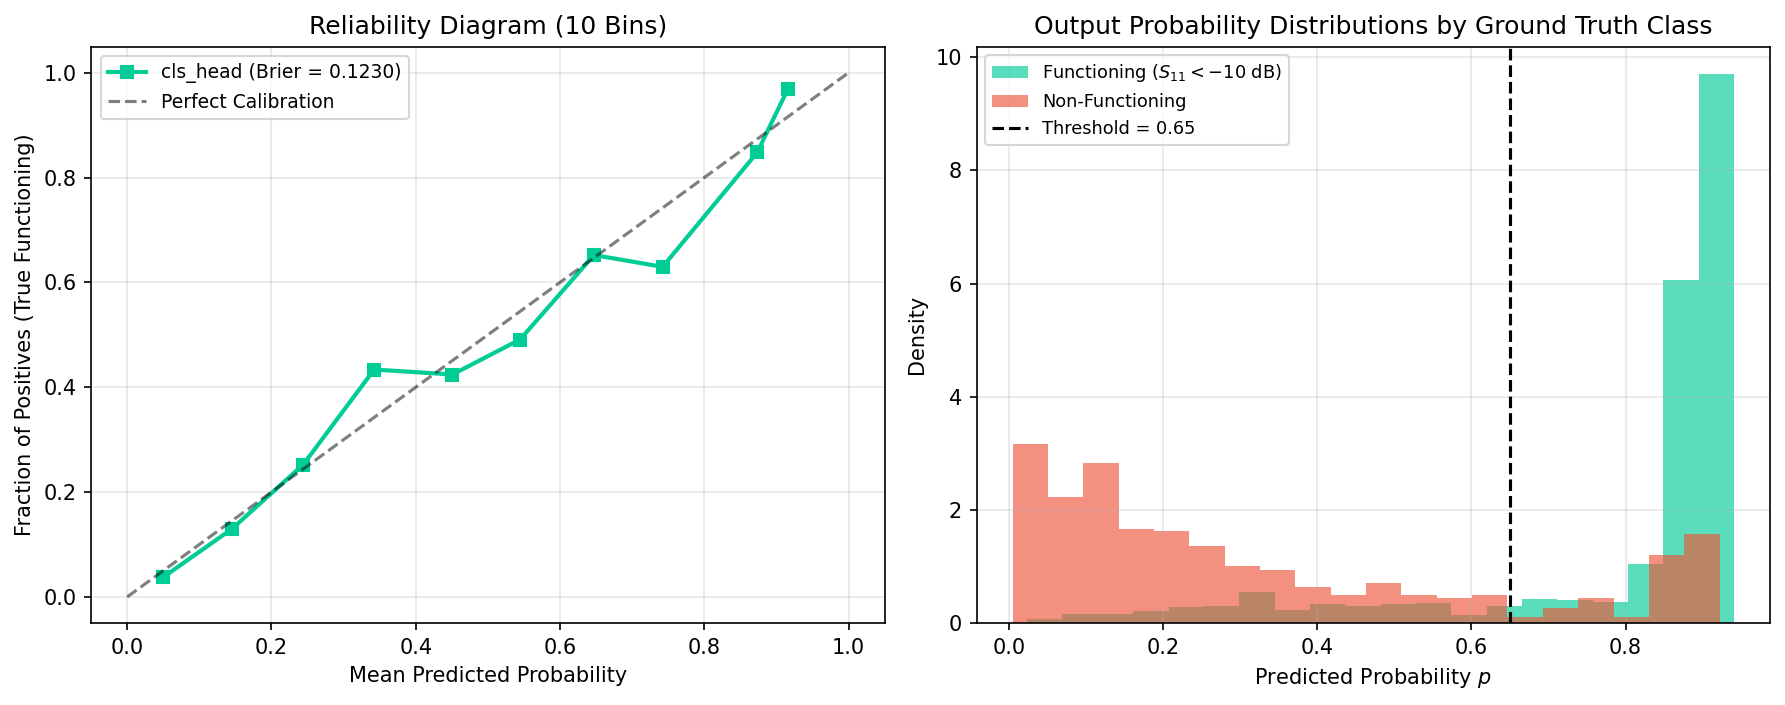

[PASS] Saved figures/ch23_calibration.png
[PASS] Saved artifacts/ch23_classifier_comparison.csv


In [7]:
# ==========================================================================
# CELL D — Validation Evaluation of Three Classifiers
# ==========================================================================

# ── Inference Helper for Single-Task Model ──
def infer_single_task(model_st, loader, desc='Inference Single-Task'):
    model_st.eval()
    records = []
    pos = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, leave=False):
            batch = batch.to(device)
            pred_norm = model_st(batch)
            pred_db = pred_norm * s11_std_dev + s11_mean_dev
            true_db = batch.y_raw.squeeze(1).to(device)
            pred_np = pred_db.detach().cpu().numpy()
            true_np = true_db.detach().cpu().numpy()

            grids = batch.grid_size
            if isinstance(grids, torch.Tensor):
                grids = grids.tolist()
            is_func_list = batch.is_functioning
            if isinstance(is_func_list, torch.Tensor):
                is_func_list = is_func_list.tolist()

            for i in range(pred_np.shape[0]):
                records.append({
                    'test_idx': pos,
                    'grid': int(grids[i]),
                    'true_min_db': float(true_np[i].min()),
                    'pred_min_db': float(pred_np[i].min()),
                    'is_functioning': bool(is_func_list[i]),
                    'true_argmin_freq': float(freq_axis[np.argmin(true_np[i])]),
                    'pred_argmin_freq': float(freq_axis[np.argmin(pred_np[i])]),
                    's11_mae': float(np.abs(pred_np[i] - true_np[i]).mean()),
                })
                pos += 1
    return pd.DataFrame(records)


# ── Inference Helper for Multi-Task Model ──
def infer_multi_task(model_mt, loader, desc='Inference Multi-Task'):
    model_mt.eval()
    records = []
    pos = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, leave=False):
            batch = batch.to(device)
            spectrum, cls_logit = model_mt(batch)
            pred_db = spectrum * s11_std_dev + s11_mean_dev
            true_db = batch.y_raw.squeeze(1).to(device)
            pred_np = pred_db.detach().cpu().numpy()
            true_np = true_db.detach().cpu().numpy()
            logit_np = cls_logit.detach().cpu().numpy()

            grids = batch.grid_size
            if isinstance(grids, torch.Tensor):
                grids = grids.tolist()
            is_func_list = batch.is_functioning
            if isinstance(is_func_list, torch.Tensor):
                is_func_list = is_func_list.tolist()

            for i in range(pred_np.shape[0]):
                p = 1.0 / (1.0 + np.exp(-logit_np[i]))
                records.append({
                    'test_idx': pos,
                    'grid': int(grids[i]),
                    'true_min_db': float(true_np[i].min()),
                    'pred_min_db': float(pred_np[i].min()),
                    'is_functioning': bool(is_func_list[i]),
                    'true_argmin_freq': float(freq_axis[np.argmin(true_np[i])]),
                    'pred_argmin_freq': float(freq_axis[np.argmin(pred_np[i])]),
                    'cls_logit': float(logit_np[i]),
                    'cls_prob': float(p),
                    's11_mae': float(np.abs(pred_np[i] - true_np[i]).mean()),
                })
                pos += 1
    return pd.DataFrame(records)


# ── Classifier Evaluation Helper ──
def classifier_metrics(labels, scores, preds):
    result = {}
    if len(np.unique(labels)) > 1:
        result['auroc'] = float(roc_auc_score(labels, scores))
        result['avg_prec'] = float(average_precision_score(labels, scores))
    else:
        result['auroc'] = float('nan')
        result['avg_prec'] = float('nan')
    result['accuracy'] = float((preds == labels).mean())
    result['bal_acc'] = float(balanced_accuracy_score(labels, preds))
    if preds.sum() > 0:
        result['precision'] = float(precision_score(labels, preds, zero_division=0))
    else:
        result['precision'] = float('nan')
    result['recall'] = float(recall_score(labels, preds, zero_division=0))
    return result


def find_best_tau(pred_mins, labels):
    tau_values = np.arange(-5.0, -13.25, -0.25)
    best_tau = -10.0
    best_ba = -1.0
    for tau in tau_values:
        pf = (pred_mins < tau).astype(int)
        ba = balanced_accuracy_score(labels, pf)
        if ba > best_ba:
            best_ba = ba
            best_tau = tau
    return float(best_tau), float(best_ba)


# ══════════════════════════════════════════════════════════════════════
# 1. Model (i): Chunk 22 Winning Arm (L2)
# ══════════════════════════════════════════════════════════════════════
print('Evaluating Model (i): Chunk 22 L2 single-task...')
ckpt_ch22 = torch.load(f'{DATA_ROOT}/checkpoints/ch22_L2.pt',
                         map_location='cpu', weights_only=False)
model_ch22 = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16,
                         num_blocks=4, output_dim=201)
model_ch22.load_state_dict(ckpt_ch22['model_state'], strict=True)
model_ch22 = model_ch22.to(device)

df_ch22 = infer_single_task(model_ch22, val_loader, desc='Eval ch22-L2')

# Load tau* from ch22 comparison table
comp_df = pd.read_csv(f'{DATA_ROOT}/artifacts/ch22_arm_comparison.csv')
ch22_tau = float(comp_df.loc[comp_df['arm'] == 'L2', 'tau_star_bal'].values[0])
print(f'  Chunk 22 L2 tau*_bal = {ch22_tau:.2f} dB')

del model_ch22, ckpt_ch22
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ══════════════════════════════════════════════════════════════════════
# 2. Models (ii) & (iii): Multi-Task Model
# ══════════════════════════════════════════════════════════════════════
print('\nEvaluating Models (ii) & (iii): Chunk 23 Multi-Task...')
ckpt_ch23 = torch.load(f'{DATA_ROOT}/checkpoints/ch23_multitask.pt',
                         map_location='cpu', weights_only=False)
model_ch23 = AntennaGNNMultiTask(hidden_dim=128, heads=8, edge_dim=16,
                                  num_blocks=4, output_dim=201)
model_ch23.load_state_dict(ckpt_ch23['model_state'], strict=True)
model_ch23 = model_ch23.to(device)

df_ch23 = infer_multi_task(model_ch23, val_loader, desc='Eval ch23-MT')

# Strategy (ii): Spectrum min-threshold tau* re-calibrated on val
ch23_tau, ch23_tau_ba = find_best_tau(
    df_ch23['pred_min_db'].values,
    df_ch23['is_functioning'].astype(int).values)
print(f'  (ii) ch23 spectrum tau*_bal = {ch23_tau:.2f} dB (Bal Acc = {ch23_tau_ba:.4f})')

# Strategy (iii): Sweep classification probability threshold
prob_thresholds = np.arange(0.05, 0.96, 0.05)
best_prob_thresh = 0.50
best_prob_ba = -1.0
labels_all = df_ch23['is_functioning'].astype(int).values
probs_all = df_ch23['cls_prob'].values

for pt in prob_thresholds:
    pf = (probs_all >= pt).astype(int)
    ba = balanced_accuracy_score(labels_all, pf)
    if ba > best_prob_ba:
        best_prob_ba = ba
        best_prob_thresh = float(pt)

print(f'  (iii) ch23 cls_head best p_thresh = {best_prob_thresh:.2f} (Bal Acc = {best_prob_ba:.4f})')

del model_ch23, ckpt_ch23
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ══════════════════════════════════════════════════════════════════════
# Build Comparison Table
# ══════════════════════════════════════════════════════════════════════

all_rows = []

for key in [35, 45, 55, 'pooled']:
    if key == 'pooled':
        sub_ch22 = df_ch22
        sub_ch23 = df_ch23
        grid_label = 'pooled'
    else:
        sub_ch22 = df_ch22[df_ch22['grid'] == key]
        sub_ch23 = df_ch23[df_ch23['grid'] == key]
        grid_label = f'{key}x{key}'

    labels = sub_ch22['is_functioning'].astype(int).values

    # (i) ch22 L2 at ch22 tau*
    scores_i = -sub_ch22['pred_min_db'].values
    preds_i = (sub_ch22['pred_min_db'].values < ch22_tau).astype(int)
    m_i = classifier_metrics(labels, scores_i, preds_i)

    # (ii) ch23 spectrum at recalibrated tau*
    scores_ii = -sub_ch23['pred_min_db'].values
    preds_ii = (sub_ch23['pred_min_db'].values < ch23_tau).astype(int)
    m_ii = classifier_metrics(labels, scores_ii, preds_ii)

    # (iii) ch23 cls_head at optimal prob threshold
    scores_iii = sub_ch23['cls_prob'].values
    preds_iii = (sub_ch23['cls_prob'].values >= best_prob_thresh).astype(int)
    m_iii = classifier_metrics(labels, scores_iii, preds_iii)

    for method, m in [
        ('(i) ch22-L2@tau*', m_i),
        ('(ii) ch23-spec@tau*', m_ii),
        ('(iii) ch23-cls_head', m_iii),
    ]:
        row = {'grid': grid_label, 'method': method, 'n': len(labels)}
        row.update(m)
        all_rows.append(row)

results_df = pd.DataFrame(all_rows)
print('\n' + '=' * 105)
print('CLASSIFIER COMPARISON (Validation Split, N=1,496)')
print('=' * 105)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))


# ── Regression Accuracy Comparison ──
print('\n' + '=' * 85)
print('REGRESSION ACCURACY IMPACT (Multi-Task vs Single-Task Baseline)')
print('=' * 85)

s11_mae_ch22 = df_ch22['s11_mae'].mean()
s11_mae_ch23 = df_ch23['s11_mae'].mean()
mae_pct_delta = (s11_mae_ch23 - s11_mae_ch22) / s11_mae_ch22 * 100

func_ch22 = df_ch22[df_ch22['is_functioning']]
func_ch23 = df_ch23[df_ch23['is_functioning']]

depth_err_ch22 = np.abs(func_ch22['pred_min_db'] - func_ch22['true_min_db']).mean()
depth_err_ch23 = np.abs(func_ch23['pred_min_db'] - func_ch23['true_min_db']).mean()

both_func_ch22 = func_ch22[func_ch22['pred_min_db'] < -10]
both_func_ch23 = func_ch23[func_ch23['pred_min_db'] < -10]

freq_err_ch22 = np.abs(both_func_ch22['pred_argmin_freq'] - both_func_ch22['true_argmin_freq']).mean()
freq_err_ch23 = np.abs(both_func_ch23['pred_argmin_freq'] - both_func_ch23['true_argmin_freq']).mean()

print(f'  Overall S11 MAE:     ch22={s11_mae_ch22:.4f} dB | ch23={s11_mae_ch23:.4f} dB | Delta: {mae_pct_delta:+.2f}%')
print(f'  Dip Depth Error:     ch22={depth_err_ch22:.2f} dB   | ch23={depth_err_ch23:.2f} dB')
print(f'  Resonance Freq Err:  ch22={freq_err_ch22:.4f} GHz | ch23={freq_err_ch23:.4f} GHz')


# ── Reliability & Calibration Curve for (iii) ──
print('\n' + '=' * 85)
print('PROBABILITY CALIBRATION & BRIER SCORE')
print('=' * 85)

labels_cal = df_ch23['is_functioning'].astype(int).values
probs_cal = df_ch23['cls_prob'].values

brier = brier_score_loss(labels_cal, probs_cal)
print(f'Brier Score: {brier:.4f}')

frac_pos, mean_pred = calibration_curve(labels_cal, probs_cal, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Panel 1: Reliability Curve
ax = axes[0]
ax.plot(mean_pred, frac_pos, 's-', color='#00cc96', lw=2,
        label=f'cls_head (Brier = {brier:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect Calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (True Functioning)')
ax.set_title('Reliability Diagram (10 Bins)')
ax.legend(fontsize=9)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

# Panel 2: Predicted Probability Distributions
ax = axes[1]
ax.hist(probs_cal[labels_cal == 1], bins=20, alpha=0.65, color='#00cc96',
        label='Functioning ($S_{11} < -10$ dB)', density=True)
ax.hist(probs_cal[labels_cal == 0], bins=20, alpha=0.65, color='#ef553b',
        label='Non-Functioning', density=True)
ax.axvline(best_prob_thresh, color='black', ls='--', lw=1.5,
           label=f'Threshold = {best_prob_thresh:.2f}')
ax.set_xlabel('Predicted Probability $p$')
ax.set_ylabel('Density')
ax.set_title('Output Probability Distributions by Ground Truth Class')
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(f'{DATA_ROOT}/figures/ch23_calibration.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'[PASS] Saved figures/ch23_calibration.png')

# ── Save Comparison Artifact ──
results_df.to_csv(f'{DATA_ROOT}/artifacts/ch23_classifier_comparison.csv', index=False)
print(f'[PASS] Saved artifacts/ch23_classifier_comparison.csv')

# Cache results for Cell E
EVAL_RESULTS = {
    'results_df': results_df,
    's11_mae_ch22': s11_mae_ch22,
    's11_mae_ch23': s11_mae_ch23,
    'mae_pct_delta': mae_pct_delta,
    'brier': brier,
}

---
## Cell E — Pre-Registered Adoption Rule

**RULE PRINTED BEFORE THE DATA:**
- **ADOPT:**
  - Classifier (iii) `cls_head` beats the best of baseline (i)/(ii) on pooled validation AUROC by $\ge 0.01$, **AND**
  - Classifier (iii) beats the best baseline on grid $55\times55$ AUROC by $\ge 0.01$, **AND**
  - Full-spectrum validation S11 MAE degrades by $\le 5\%$ vs. Chunk 22 single-task winner, **AND**
  - The permutation-invariance guard passes in Cell F.
- **REJECT:** S11 MAE degrades by $> 5\%$, or AUROC does not improve. In that case, single-task model with calibrated $\tau^*$ is the deliverable.
- **MIXED:** AUROC improves on some grids but not on $55\times55$ or pooled; report both, adopt neither for automatic pipeline transition.

In [8]:
# ==========================================================================
# CELL E — Pre-Registered Adoption Rule
# ==========================================================================

print('=' * 85)
print('PRE-REGISTERED ADOPTION RULE')
print('=' * 85)
print("""
ADOPT  if classifier (iii) [cls_head] satisfies:
         1. Pooled Val AUROC gain >= 0.01 over best baseline (i)/(ii)
         2. Grid 55x55 Val AUROC gain >= 0.01 over best baseline (i)/(ii)
         3. Validation S11 MAE degradation <= 5.0% vs Chunk 22 winner
         4. Permutation-invariance guard (Cell F) passes

REJECT if S11 MAE degrades by > 5.0%, or AUROC does not improve.
       Single-task model with swept threshold is the deliverable.

MIXED  otherwise: report both models, adopt neither.
""")

print('-' * 85)
print('DECIDING NUMBERS')
print('-' * 85)

rdf = EVAL_RESULTS['results_df']
s11_mae_ch22 = EVAL_RESULTS['s11_mae_ch22']
s11_mae_ch23 = EVAL_RESULTS['s11_mae_ch23']
mae_pct_delta = EVAL_RESULTS['mae_pct_delta']

# Pooled AUROC
auroc_i_pooled = float(rdf.loc[(rdf['grid'] == 'pooled') & (rdf['method'] == '(i) ch22-L2@tau*'), 'auroc'].values[0])
auroc_ii_pooled = float(rdf.loc[(rdf['grid'] == 'pooled') & (rdf['method'] == '(ii) ch23-spec@tau*'), 'auroc'].values[0])
auroc_iii_pooled = float(rdf.loc[(rdf['grid'] == 'pooled') & (rdf['method'] == '(iii) ch23-cls_head'), 'auroc'].values[0])

best_baseline_pooled = max(auroc_i_pooled, auroc_ii_pooled)
auroc_gain_pooled = auroc_iii_pooled - best_baseline_pooled

# 55x55 AUROC
auroc_i_55 = float(rdf.loc[(rdf['grid'] == '55x55') & (rdf['method'] == '(i) ch22-L2@tau*'), 'auroc'].values[0])
auroc_ii_55 = float(rdf.loc[(rdf['grid'] == '55x55') & (rdf['method'] == '(ii) ch23-spec@tau*'), 'auroc'].values[0])
auroc_iii_55 = float(rdf.loc[(rdf['grid'] == '55x55') & (rdf['method'] == '(iii) ch23-cls_head'), 'auroc'].values[0])

best_baseline_55 = max(auroc_i_55, auroc_ii_55)
auroc_gain_55 = auroc_iii_55 - best_baseline_55

print(f'  Pooled AUROC:    (i)={auroc_i_pooled:.4f}  (ii)={auroc_ii_pooled:.4f}  (iii)={auroc_iii_pooled:.4f}')
print(f'  Pooled Gain:     {auroc_gain_pooled:+.4f} (Required: >= +0.0100)')

print(f'\n  55x55 AUROC:     (i)={auroc_i_55:.4f}  (ii)={auroc_ii_55:.4f}  (iii)={auroc_iii_55:.4f}')
print(f'  55x55 Gain:      {auroc_gain_55:+.4f} (Required: >= +0.0100)')

print(f'\n  S11 MAE Impact:  ch22={s11_mae_ch22:.4f} dB -> ch23={s11_mae_ch23:.4f} dB ({mae_pct_delta:+.2f}%)')
print(f'  MAE Degradation: {mae_pct_delta:+.2f}% (Allowed: <= +5.00%)')

# ── Evaluate Conditions ──
auroc_ok_pooled = auroc_gain_pooled >= 0.01
auroc_ok_55 = auroc_gain_55 >= 0.01
mae_ok = mae_pct_delta <= 5.0

print('\n' + '=' * 85)
print('VERDICT EVALUATION')
print('=' * 85)

if auroc_ok_pooled and auroc_ok_55 and mae_ok:
    decision = 'ADOPT (pending Cell F permutation guard)'
    print(f'\n  Decision: {decision}')
    print(f'  - Pooled AUROC gain (+{auroc_gain_pooled:.4f}) >= 0.01 [PASS]')
    print(f'  - 55x55 AUROC gain  (+{auroc_gain_55:.4f}) >= 0.01 [PASS]')
    print(f'  - S11 MAE delta     ({mae_pct_delta:+.2f}%) <= 5%  [PASS]')
    print(f'  -> Recommendation: ADOPT multi-task architecture for Stage 1 surrogate pipeline.')
elif not mae_ok:
    decision = 'REJECT'
    print(f'\n  Decision: {decision}')
    print(f'  - S11 MAE degraded by {mae_pct_delta:+.2f}% (> 5.0% limit).')
    print(f'  -> The classification head imposes unacceptable gradient interference on regression.')
    print(f'  -> Single-task AntennaGNN with swept decision threshold remains the primary deliverable.')
elif not (auroc_ok_pooled and auroc_ok_55):
    if auroc_gain_pooled >= 0.01 or auroc_gain_55 >= 0.01:
        decision = 'MIXED'
        print(f'\n  Decision: {decision}')
        print(f'  - Pooled AUROC gain: {auroc_gain_pooled:+.4f} ({"PASS" if auroc_ok_pooled else "FAIL"})')
        print(f'  - 55x55 AUROC gain:  {auroc_gain_55:+.4f} ({"PASS" if auroc_ok_55 else "FAIL"})')
        print(f'  -> Inconsistent cross-grid gains; adopt nothing, report both.')
    else:
        decision = 'REJECT'
        print(f'\n  Decision: {decision}')
        print(f'  - Insufficient classification gain (pooled: {auroc_gain_pooled:+.4f}, 55x55: {auroc_gain_55:+.4f}).')
        print(f'  -> Multi-task head did not provide meaningful classification separation.')

print(f'\n  Branch Triggered: {decision}')

PRE-REGISTERED ADOPTION RULE

ADOPT  if classifier (iii) [cls_head] satisfies:
         1. Pooled Val AUROC gain >= 0.01 over best baseline (i)/(ii)
         2. Grid 55x55 Val AUROC gain >= 0.01 over best baseline (i)/(ii)
         3. Validation S11 MAE degradation <= 5.0% vs Chunk 22 winner
         4. Permutation-invariance guard (Cell F) passes

REJECT if S11 MAE degrades by > 5.0%, or AUROC does not improve.
       Single-task model with swept threshold is the deliverable.

MIXED  otherwise: report both models, adopt neither.

-------------------------------------------------------------------------------------
DECIDING NUMBERS
-------------------------------------------------------------------------------------
  Pooled AUROC:    (i)=0.8993  (ii)=0.9016  (iii)=0.8989
  Pooled Gain:     -0.0027 (Required: >= +0.0100)

  55x55 AUROC:     (i)=0.7881  (ii)=0.7814  (iii)=0.7892
  55x55 Gain:      +0.0011 (Required: >= +0.0100)

  S11 MAE Impact:  ch22=0.3570 dB -> ch23=0.3597 dB (+0.76

---
## Cell F — Integrity Guards & Permutation Invariance

**Pillar 1 Invariance Verification:**
- Applies 20 random node permutations to a fixed validation graph.
- Asserts $\text{std}(\hat{S}_{11}) < 10^{-5}$ dB and $\text{std}(\text{logit}_{\text{cls}}) < 10^{-5}$.
- Verifies exact parameter count ($587,258$), 4 GATv2 blocks with 2 sub-layers each, and guarantees the test split was never accessed.

In [9]:
# ==========================================================================
# CELL F — Integrity Guards & Permutation Invariance
# ==========================================================================

print('=' * 85)
print('MANDATORY INTEGRITY GUARDS')
print('=' * 85)

# ── Guard (a): Permutation Invariance (Pillar 1) ──
print('\nGuard (a): Permutation Invariance Test (20 Random Permutations)...')

ckpt = torch.load(f'{DATA_ROOT}/checkpoints/ch23_multitask.pt',
                   map_location='cpu', weights_only=False)
perm_model = AntennaGNNMultiTask(
    hidden_dim=128, heads=8, edge_dim=16,
    num_blocks=4, output_dim=201)
perm_model.load_state_dict(ckpt['model_state'], strict=True)
perm_model = perm_model.to(device)
perm_model.eval()
del ckpt

# Select a fixed validation graph
sample_graph = val_ds[42]
n_nodes = sample_graph.x.size(0)
sample_graph.batch = torch.zeros(n_nodes, dtype=torch.long)

# ── Guard on the guard: verify inverse permutation preserves edge adjacency ──
test_perm = torch.randperm(n_nodes)
test_inv_perm = torch.empty_like(test_perm)
test_inv_perm[test_perm] = torch.arange(n_nodes)
test_new_edge_index = test_inv_perm[sample_graph.edge_index]

n_edges = sample_graph.edge_index.size(1)
rand_edge_indices = torch.randperm(n_edges)[:min(5, n_edges)]
new_edges_set = set(zip(test_new_edge_index[0].tolist(), test_new_edge_index[1].tolist()))

for e_idx in rand_edge_indices:
    u = sample_graph.edge_index[0, e_idx].item()
    v = sample_graph.edge_index[1, e_idx].item()
    u_new = test_inv_perm[u].item()
    v_new = test_inv_perm[v].item()
    assert (u_new, v_new) in new_edges_set, (
        f'Edge remapping failed: original edge ({u}, {v}) -> ({u_new}, {v_new}) not found in permuted edge_index'
    )
print('[PASS] Edge remapping preserves adjacency under permutation')

spectra_trials = []
logits_trials = []

torch.manual_seed(42)  # reproducible permutations
with torch.no_grad():
    for trial in range(20):
        perm = torch.randperm(n_nodes)
        inv_perm = torch.empty_like(perm)
        inv_perm[perm] = torch.arange(n_nodes)

        pdata = sample_graph.clone()
        pdata.x = sample_graph.x[perm]
        pdata.edge_index = inv_perm[sample_graph.edge_index]
        pdata.batch = sample_graph.batch[perm]

        pdata = pdata.to(device)
        spec, logit = perm_model(pdata)

        # De-normalize predicted spectrum to dB
        spec_db = spec * s11_std_dev + s11_mean_dev
        spectra_trials.append(spec_db.cpu())
        logits_trials.append(logit.cpu())

spectra_t = torch.stack(spectra_trials)  # (20, 201)
logits_t = torch.stack(logits_trials)    # (20,)

spec_std_max = float(spectra_t.std(dim=0).max().item())
logit_std = float(logits_t.std().item())

print(f'  Spectrum Prediction std (max over freq): {spec_std_max:.2e} dB')
print(f'  Classification Logit std:                {logit_std:.2e}')

assert spec_std_max < 1e-5, f'GUARD (a) FAILED: spectrum std {spec_std_max:.2e} >= 1e-5 dB'
assert logit_std < 1e-5, f'GUARD (a) FAILED: cls logit std {logit_std:.2e} >= 1e-5'
print(f'[PASS] Guard (a): Permutation invariance preserved for both spectrum and cls_head!')

del perm_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ── Guard (b): Parameter Count (587,258) ──
ckpt = torch.load(f'{DATA_ROOT}/checkpoints/ch23_multitask.pt',
                   map_location='cpu', weights_only=False)
check_model = AntennaGNNMultiTask(
    hidden_dim=128, heads=8, edge_dim=16,
    num_blocks=4, output_dim=201)
check_model.load_state_dict(ckpt['model_state'], strict=True)

n_params = sum(p.numel() for p in check_model.parameters())
assert n_params == 587_258, f'GUARD (b) FAILED: expected 587,258 params, got {n_params:,}'
print(f'[PASS] Guard (b): Exact parameter count = {n_params:,}')


# ── Guard (c): 4 Blocks x 2 Layers ──
assert len(check_model.blocks) == 4, f'GUARD (c) FAILED: {len(check_model.blocks)} blocks'
for i, block_pair in enumerate(check_model.blocks):
    assert len(block_pair) == 2, f'GUARD (c) FAILED: block {i} has {len(block_pair)} layers'
print(f'[PASS] Guard (c): 4 blocks x 2 sub-layers verified')

del check_model, ckpt


# ── Guard (d): Test Split Untouched ──
assert not TEST_INDICES_LOADED, 'GUARD (d) FAILED: test indices were loaded in memory'
print(f'[PASS] Guard (d): Test split remained completely untouched')

print('\n' + '=' * 85)
print('ALL CHUNK 23 INTEGRITY GUARDS PASSED [OK]')
print('=' * 85)

MANDATORY INTEGRITY GUARDS

Guard (a): Permutation Invariance Test (20 Random Permutations)...
[PASS] Edge remapping preserves adjacency under permutation
  Spectrum Prediction std (max over freq): 5.83e-06 dB
  Classification Logit std:                3.44e-07
[PASS] Guard (a): Permutation invariance preserved for both spectrum and cls_head!
[PASS] Guard (b): Exact parameter count = 587,258
[PASS] Guard (c): 4 blocks x 2 sub-layers verified
[PASS] Guard (d): Test split remained completely untouched

ALL CHUNK 23 INTEGRITY GUARDS PASSED [OK]
